In [4]:
!pip install -q -U kagglehub

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

def load():
    # Local CSV first (if you uploaded it), else download via kagglehub
    local = glob.glob("zomato*.csv")
    if local:
        path_csv = local[0]
    else:
        import kagglehub
        path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")
        csvs = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
        print("Files found:", csvs)
        path_csv = csvs[0]
    try:
        return pd.read_csv(path_csv)
    except UnicodeDecodeError:
        return pd.read_csv(path_csv, encoding="latin-1")

df = load()
df_raw = df.copy()          # untouched copy for before/after comparison
print("Shape:", df.shape)
display(df.head())

100%|██████████| 89.0M/89.0M [00:01<00:00, 88.0MB/s]

Extracting files...


Files found: ['/root/.cache/kagglehub/datasets/himanshupoddar/zomato-bangalore-restaurants/versions/1/zomato.csv']
Shape: (51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
df_raw = df.copy()

print("Raw dataset shape:", df_raw.shape)

Raw dataset shape: (51717, 17)


In [23]:
# Basic quality assessment
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51717 non-null  object 
 1   address                      51717 non-null  object 
 2   name                         51717 non-null  object 
 3   online_order                 51717 non-null  object 
 4   book_table                   51717 non-null  object 
 5   rate                         51717 non-null  float64
 6   votes                        51717 non-null  int64  
 7   location                     51717 non-null  object 
 8   rest_type                    51717 non-null  object 
 9   cuisines                     51717 non-null  object 
 10  approx_cost(for two people)  51717 non-null  float64
 11  reviews_list                 51717 non-null  object 
 12  menu_item                    51717 non-null  object 


### Duplicate Rows

The dataset contains 0 duplicate rows. Therefore, no duplicate records were removed.
The original row count of 51,717 is retained for the cleaning process.

In [8]:
# Missing value percentage
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)

display(missing)

,Missing Count,Missing Percentage
dish_liked,28078,54.29
rate,7775,15.03
phone,1208,2.34
approx_cost(for two people),346,0.67
rest_type,227,0.44
cuisines,45,0.09
location,21,0.04


### Missing Value Handling Strategy

The missing values were reviewed column by column rather than applying a blanket `dropna()` strategy.

- **dish_liked (54.29%)**: More than half of the values are missing. Since this is a descriptive preference field and imputing a value would create misleading information, the column will be dropped.
- **rate (15.03%)**: Ratings are important for analysis, so missing values will be preserved initially and handled after cleaning the inconsistent rating format.
- **phone (2.34%)**: Phone numbers are contact information and are not required for analysis, so the column will be dropped.
- **approx_cost(for two people) (0.67%)**: This is a numeric cost field. Missing values will be imputed using the median after converting the column to numeric format because the median is less affected by extreme prices.
- **rest_type (0.44%)**: This categorical variable will be imputed with the mode because the missing percentage is very small.
- **cuisines (0.09%)**: Missing values will be replaced with the mode because very few records are affected.
- **location (0.04%)**: Missing values will be replaced with the mode because the missing percentage is negligible.

In [9]:
print("Sample rate values:")
print(df["rate"].dropna().unique()[:30])

print("\nSample cost values:")
print(df["approx_cost(for two people)"].dropna().unique()[:30])

Sample rate values:
['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5'
 '2.6/5' '3.8 /5' '3.4/5' '4.5/5' '2.5/5' '2.7/5' '4.7/5' '2.4/5' '2.2/5'
 '2.3/5' '3.4 /5' '-']

Sample cost values:
['800' '300' '600' '700' '550' '500' '450' '650' '400' '900' '200' '750'
 '150' '850' '100' '1,200' '350' '250' '950' '1,000' '1,500' '1,300' '199'
 '80' '1,100' '160' '1,600' '230' '130' '50']


In [11]:
# Clean the rating column
df["rate"] = (
    df["rate"]
    .replace(["NEW", "-"], np.nan)
    .astype(str)
    .str.replace("/5", "", regex=False)
)

df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

print("Rate datatype:", df["rate"].dtype)
print("Missing ratings after cleaning:", df["rate"].isna().sum())
print(df["rate"].describe())

Rate datatype: float64
Missing ratings after cleaning: 10052
count    41665.000000
mean         3.700449
std          0.440513
min          1.800000
25%          3.400000
50%          3.700000
75%          4.000000
max          4.900000
Name: rate, dtype: float64


In [13]:
# Clean the cost column
df["approx_cost(for two people)"] = (
    df["approx_cost(for two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"],
    errors="coerce"
)

print("Cost datatype:", df["approx_cost(for two people)"].dtype)
print("Missing costs:", df["approx_cost(for two people)"].isna().sum())
print(df["approx_cost(for two people)"].describe())

Cost datatype: float64
Missing costs: 346
count    51371.000000
mean       555.431566
std        438.850728
min         40.000000
25%        300.000000
50%        400.000000
75%        650.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64


In [14]:
# Fill missing ratings with median
rate_median = df["rate"].median()
df["rate"] = df["rate"].fillna(rate_median)

print("Missing rate after imputation:", df["rate"].isna().sum())
print("Rate median used:", rate_median)

Missing rate after imputation: 0
Rate median used: 3.7


In [15]:
# Fill missing cost with median
cost_median = df["approx_cost(for two people)"].median()
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].fillna(cost_median)

print("Missing cost after imputation:", df["approx_cost(for two people)"].isna().sum())
print("Cost median used:", cost_median)

Missing cost after imputation: 0
Cost median used: 400.0


In [16]:
# Drop phone column because it is not required for analysis
df = df.drop(columns=["phone"])

print("Phone column dropped.")
print("Current shape:", df.shape)

Phone column dropped.
Current shape: (51717, 16)


In [17]:
# Drop dish_liked because more than 50% of its values are missing
df = df.drop(columns=["dish_liked"])

print("dish_liked column dropped due to high missing percentage.")
print("Current shape:", df.shape)

dish_liked column dropped due to high missing percentage.
Current shape: (51717, 15)


In [18]:
# Check remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining missing values:")
print(remaining_missing)

Remaining missing values:
rest_type    227
cuisines      45
location      21
dtype: int64


In [19]:
# Fill missing rest_type values with the most frequent category (mode)
rest_type_mode = df["rest_type"].mode()[0]

df["rest_type"] = df["rest_type"].fillna(rest_type_mode)

print("rest_type missing after imputation:", df["rest_type"].isna().sum())
print("Mode used:", rest_type_mode)

rest_type missing after imputation: 0
Mode used: Quick Bites


In [20]:
cuisines_mode = df["cuisines"].mode()[0]
df["cuisines"] = df["cuisines"].fillna(cuisines_mode)

print("cuisines missing after imputation:", df["cuisines"].isna().sum())
print("Mode used:", cuisines_mode)

cuisines missing after imputation: 0
Mode used: North Indian


In [21]:
location_mode = df["location"].mode()[0]
df["location"] = df["location"].fillna(location_mode)

print("location missing after imputation:", df["location"].isna().sum())
print("Mode used:", location_mode)

location missing after imputation: 0
Mode used: BTM


In [22]:
# Final check for missing values
print("Total missing values:", df.isnull().sum().sum())

remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

print("\nColumns still having missing values:")
print(remaining)

Total missing values: 0

Columns still having missing values:
Series([], dtype: int64)


In [24]:
# Check dataset shape after cleaning
print("Original shape:", df_raw.shape)
print("Cleaned shape:", df.shape)
print("Rows removed:", df_raw.shape[0] - df.shape[0])
print("Columns removed:", df_raw.shape[1] - df.shape[1])

Original shape: (51717, 17)
Cleaned shape: (51717, 15)
Rows removed: 0
Columns removed: 2


In [25]:
# Check numeric columns for outlier analysis
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

Numeric columns:
['rate', 'votes', 'approx_cost(for two people)']


In [26]:
# Detect outliers using the IQR method

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outliers": outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,rate,3.5,3.9,0.4,2.9,4.5,2845
1,votes,7.0,198.0,191.0,-279.5,484.5,6961
2,approx_cost(for two people),300.0,650.0,350.0,-225.0,1175.0,4764


## Outlier Handling Decisions

Outliers were detected using the Interquartile Range (IQR) method.

- **rate:** The IQR method flagged 2,845 observations. These values fall within a realistic restaurant rating range of approximately 1.8 to 4.9. They are valid ratings rather than data-entry errors, so they were retained.

- **votes:** The IQR method flagged 6,961 observations. The number of votes is naturally right-skewed because popular restaurants receive much more engagement than others. These high values represent genuine popularity, so they were retained.

- **approx_cost(for two people):** The IQR method flagged 4,764 observations. Higher costs can represent premium or fine-dining restaurants and are not necessarily errors. Therefore, these observations were retained.

**Conclusion:** No numeric outliers were removed because the flagged observations could represent genuine characteristics of restaurants rather than data-entry errors.

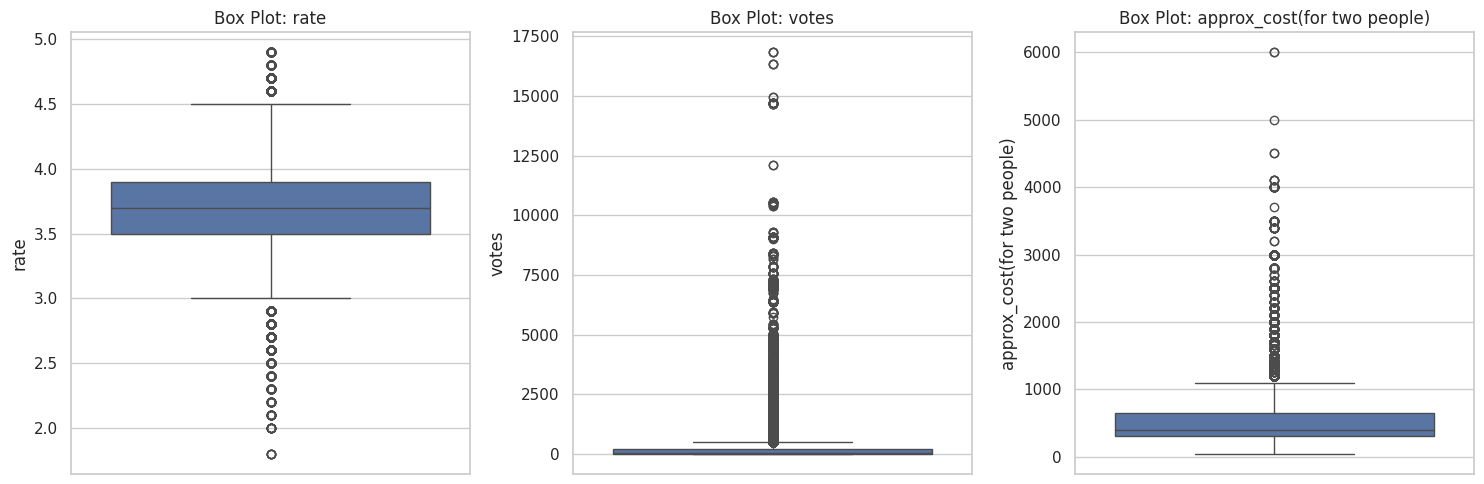

In [28]:
# Visual inspection of numeric variables using box plots

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Box Plot: {col}")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [29]:
# Categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['url', 'address', 'name', 'online_order', 'book_table', 'location', 'rest_type', 'cuisines', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


In [30]:
# Select categorical columns suitable for encoding
encoding_cols = [
    "online_order",
        "book_table"
        ]
print("Columns selected for encoding:")
print(encoding_cols)

Columns selected for encoding:
['online_order', 'book_table']


In [31]:
# Convert Yes/No categorical variables into binary values

df["online_order"] = df["online_order"].map({"Yes": 1, "No": 0})
df["book_table"] = df["book_table"].map({"Yes": 1, "No": 0})

print("Encoding completed.")
print(df[["online_order", "book_table"]].head())

Encoding completed.
   online_order  book_table
0             1           1
1             1           0
2             1           0
3             0           0
4             0           0


In [32]:
# Before vs After: Dataset Shape

print("BEFORE CLEANING:")
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nAFTER CLEANING:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nRows removed:", df_raw.shape[0] - df.shape[0])
print("Columns removed:", df_raw.shape[1] - df.shape[1])

BEFORE CLEANING:
Rows: 51717
Columns: 17

AFTER CLEANING:
Rows: 51717
Columns: 15

Rows removed: 0
Columns removed: 2


In [34]:
# Before vs After: Missing Values

before_missing = df_raw.isnull().sum()
after_missing = df.isnull().sum()

comparison = pd.DataFrame({
    "Before Cleaning": before_missing,
    "After Cleaning": after_missing
})

comparison = comparison[
    (comparison["Before Cleaning"] > 0) |
    (comparison["After Cleaning"] > 0)
]

print("Missing Values Before vs After:")
display(comparison)

Missing Values Before vs After:


,Before Cleaning,After Cleaning
approx_cost(for two people),346,0.0
cuisines,45,0.0
dish_liked,28078,NaN
location,21,0.0
phone,1208,NaN
rate,7775,0.0
rest_type,227,0.0


In [35]:
# Before vs After: Summary Statistics

print("BEFORE CLEANING - Numeric Summary:")
display(df_raw[["votes"]].describe())

print("\nAFTER CLEANING - Numeric Summary:")
display(df[["votes", "rate", "approx_cost(for two people)"]].describe())

BEFORE CLEANING - Numeric Summary:


,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000



AFTER CLEANING - Numeric Summary:


,votes,rate,approx_cost(for two people)
count,51717.000000,51717.000000,51717.000000
mean,283.697527,3.700362,554.391689
std,803.838853,0.395391,437.563723
min,0.000000,1.800000,40.000000
25%,7.000000,3.500000,300.000000
50%,41.000000,3.700000,400.000000
75%,198.000000,3.900000,650.000000
max,16832.000000,4.900000,6000.000000


In [36]:
# Final Dataset Quality Check

print("FINAL DATASET SHAPE:", df.shape)
print("\nTotal Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

print("\nFinal Data Types:")
print(df.dtypes)

FINAL DATASET SHAPE: (51717, 15)

Total Missing Values: 0
Total Duplicate Rows: 0

Final Data Types:
url                             object
address                         object
name                            object
online_order                     int64
book_table                       int64
rate                           float64
votes                            int64
location                        object
rest_type                       object
cuisines                        object
approx_cost(for two people)    float64
reviews_list                    object
menu_item                       object
listed_in(type)                 object
listed_in(city)                 object
dtype: object


## Final Cleaning Summary

The dataset was cleaned using a column-wise and justified preprocessing approach.

- Duplicate rows: No duplicate rows were found, so no rows were removed.
- Missing `rate` values: Converted inconsistent values such as "NEW" and "-" to missing values and imputed them using the median (3.7).
- Missing `approx_cost(for two people)` values: Converted the cost column to numeric format and imputed missing values using the median (400).
- Missing `rest_type`, `cuisines`, and `location`: Imputed using the mode because their missing percentages were very small.
- `phone`: Removed because it is contact information and is not required for the analysis.
- `dish_liked`: Removed because more than 50% of its values were missing.
- Outliers: Detected using the IQR method. No numeric outliers were removed because the flagged values represented genuine differences in restaurant ratings, popularity, and pricing.
- Categorical variables: `online_order` and `book_table` were encoded into binary 0/1 values.

The final dataset contains 51,717 rows and 15 columns with zero missing values and zero duplicate rows.

## Key Findings

1. The original dataset contained 51,717 rows and 17 columns.
2. Two columns (`phone` and `dish_liked`) were removed because they were not suitable for the analysis due to irrelevance or excessive missing values.
3. Missing values in important analytical columns were handled using justified median or mode imputation rather than dropping all incomplete rows.
4. The IQR method identified outliers in ratings, votes, and restaurant cost, but they were retained because they represented genuine real-world variation rather than obvious data-entry errors.
5. Binary categorical variables such as `online_order` and `book_table` were successfully encoded into numerical 0/1 values.
6. After cleaning, the dataset contains zero missing values and zero duplicate rows, making it ready for downstream analysis and machine learning.